In [44]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms.v2 as transforms
import pandas as pd
import numpy as np
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt


In [45]:

def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

set_seed(SEED)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA
device = torch.device("cuda")

In [46]:

base_transform = transforms.Compose(
    [
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ])

In [47]:

full_trainset = torchvision.datasets.ImageFolder("trafic_32", transform=base_transform)

train_ratio = 0.9
num_classes = len(full_trainset.classes)

full_trainset_size = len(full_trainset)
train_size = int(train_ratio * full_trainset_size)
validation_size = full_trainset_size - train_size
trainset, valset = torch.utils.data.random_split(
    full_trainset, [train_size, validation_size]
)

In [48]:
temp_transform = transforms.Compose(
    [
        transforms.Resize(64),
    ]
)

In [49]:
# all_samples = torch.stack([temp_transform(sample[0]) for sample in trainset])
# mean = all_samples.mean(axis=(0,2,3))
# std=all_samples.std(axis=(0,2,3))
# print(f"Data norm per channel: mean={mean} | std={std}")
# all_samples = None

In [50]:

mean = torch.tensor([0.3187, 0.2932, 0.3019])
std = torch.tensor([0.2687, 0.2571, 0.2605])

In [51]:
class WrappedSubset:
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.classes = subset.dataset.classes
        self.targets = [subset.dataset.targets[i] for i in subset.indices]

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [52]:

train_transform = transforms.Compose(
    [
        transforms.Resize((28, 28)),
        transforms.RandomCrop(28, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.TrivialAugmentWide(),
        transforms.Normalize(mean=mean, std=std),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize((28, 28)),
        transforms.Normalize(mean=mean, std=std),
    ]
)

trainset = WrappedSubset(trainset, transform=train_transform)
valset = WrappedSubset(valset, transform=test_transform)

In [53]:

batch_size = 128
shuffle = True
num_workers = 12
prefetch_factor = 4
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=shuffle,
    num_workers=num_workers,
    pin_memory=True,
    prefetch_factor=prefetch_factor,
    persistent_workers=True,
    drop_last=True,
    )
valloader = torch.utils.data.DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    prefetch_factor=prefetch_factor,
    persistent_workers=True,
    )

In [54]:

class BasicUNet(nn.Module):
    """A minimal UNet implementation."""
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down_layers = torch.nn.ModuleList([
            nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.Conv2d(64, 64, kernel_size=5, padding=2),
        ])
        self.up_layers = torch.nn.ModuleList([
            nn.Conv2d(64 + 1, 64, kernel_size=5, padding=2), #Dodajmy warunkowanie "krokiem odszumiania"
            nn.Conv2d(64, 32, kernel_size=5, padding=2),
            nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
        ])
        self.act = nn.SiLU() # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x, t):
        h = []
        for i, layer in enumerate(self.down_layers):
            x = self.act(layer(x))
            if i < 2: # Dla wszystki warstw "down" poza ostatnim
              h.append(x) # Zapisujemy "skip-connetions"
              x = self.downscale(x) # Zmniejszamy wymiarowość, i propagujemy do kolejnej warstwy
        t = t.repeat(1,x.size(2),x.size(3),1).permute(3,0,1,2)
        x = torch.cat([x,t],dim=1)
        for i, layer in enumerate(self.up_layers):
            if i > 0: # Dla wszystkich warstw up poza pierwszą
              x = self.upscale(x) # Upscale
              x += h.pop() # Dodajemy zapisane skip-connection
            x = self.act(layer(x))

        return x

In [55]:
net = BasicUNet().to(device)
net

BasicUNet(
  (down_layers): ModuleList(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (up_layers): ModuleList(
    (0): Conv2d(65, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (act): SiLU()
  (downscale): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (upscale): Upsample(scale_factor=2.0, mode='nearest')
)

In [56]:

def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
    return x*(1-amount) + noise*amount

Finished epoch 0. Average loss for this epoch: 0.453560
Finished epoch 1. Average loss for this epoch: 0.373497
Finished epoch 2. Average loss for this epoch: 0.362755
Finished epoch 3. Average loss for this epoch: 0.357399
Finished epoch 4. Average loss for this epoch: 0.354980
Finished epoch 5. Average loss for this epoch: 0.348264
Finished epoch 6. Average loss for this epoch: 0.350021
Finished epoch 7. Average loss for this epoch: 0.349430
Finished epoch 8. Average loss for this epoch: 0.348409
Finished epoch 9. Average loss for this epoch: 0.349034
Finished epoch 10. Average loss for this epoch: 0.344711
Finished epoch 11. Average loss for this epoch: 0.343952
Finished epoch 12. Average loss for this epoch: 0.343712
Finished epoch 13. Average loss for this epoch: 0.342771
Finished epoch 14. Average loss for this epoch: 0.344506
Finished epoch 15. Average loss for this epoch: 0.342516
Finished epoch 16. Average loss for this epoch: 0.345196
Finished epoch 17. Average loss for this 

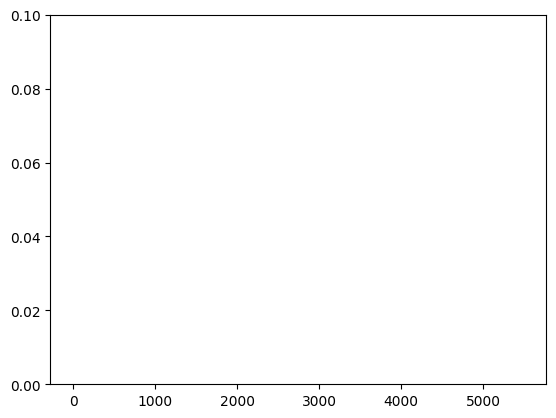

In [57]:

n_epochs = 20

# Funkcja straty - zwykłe MSE
loss_fn = nn.MSELoss()

# Optymalizator
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

# Wartości funkcji straty
losses = []

# The training loop
for epoch in range(n_epochs):

    for x, y in trainloader:

        # Przygotowanie danych
        x = x.to(device)
        # Losowanie ilości dodanego szumu - może być krok, albo jak w tym przypadku ciągła wartość w %
        noise_amount = torch.rand(x.shape[0]).to(device) 
        noisy_x = corrupt(x, noise_amount) # Zaszumiony przykład

        # Predykcja oryginalnego - czystego obrazka
        pred = net(noisy_x, noise_amount)

        # Porównanie z oryginalnym obrazkiem
        loss = loss_fn(pred, x) # 
 
        opt.zero_grad()
        loss.backward()        
        opt.step()

        losses.append(loss.item())

    # Średni loss per epoka:
    avg_loss = sum(losses[-len(trainloader):])/len(trainloader)
    print(f'Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}')

# View the loss curve
plt.plot(losses)
plt.ylim(0, 0.1);

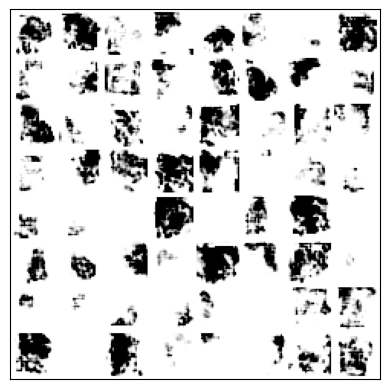

In [60]:
from torchvision.transforms.functional import to_pil_image
#Showing more results, using 40 sampling steps
n_steps = 40
x = torch.rand(64, 3, 28, 28).to(device)
for i in range(n_steps):
  t = (torch.zeros(x.size(0)) + (n_steps - i)/n_steps).to(device)
  noise_amount = torch.ones((x.shape[0], )).to(device) * (1-(i/n_steps)) # Starting high going low
  with torch.no_grad():
    pred = net(x, t)
#-----------Samplowanie
    mix_factor = 1/(n_steps - i)
    x = x*(1-mix_factor) + pred*mix_factor
#----------------------
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = to_pil_image(img)
        axs[0, i].imshow(np.asarray(img), cmap="Greys")
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
grid = torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1)
show(grid)

In [59]:
print(x.shape)

torch.Size([64, 3, 28, 28])
